# [Milvus 벡터 데이터베이스](https://milvus.io/ko/intro)


## 1. Milvus란?
> Milvus는 오픈소스 벡터 데이터베이스로, 대규모 벡터 검색과 머신러닝 애플리케이션을 위한 고성능 데이터 저장소입니다.

### 주요 특징
- **고성능**: 밀리초 단위의 벡터 검색 성능
- **확장성**: 수십억 개의 벡터를 처리할 수 있는 수평적 확장
- **다양한 인덱스**: IVF, HNSW, ANNOY 등 다양한 벡터 인덱스 지원
- **클라우드 네이티브**: Kubernetes 환경에서 완벽하게 동작
- **다양한 API**: RESTful API, Python SDK, Java SDK 등 제공


### [RAG에서의 활용](https://milvus.io/ko/bootcamp)
- 문서 임베딩 벡터 저장
- 의미 기반 유사 문서 검색
- 하이브리드 검색 (벡터 + 키워드)
- 멀티모달 검색 지원

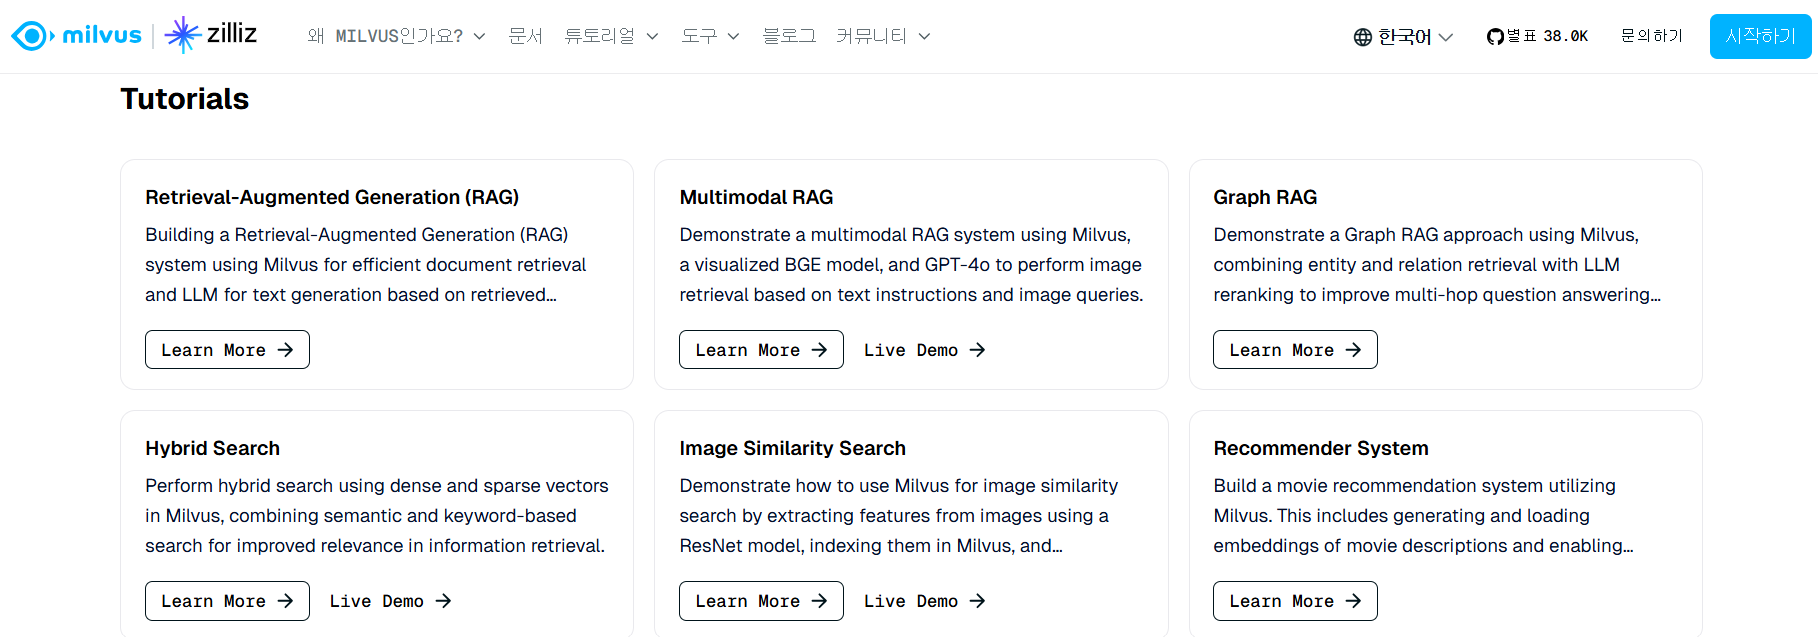

### Milvus는 어떻게 작동하나요?
> Milvus는 벡터 데이터를 효율적으로 처리하고 확장성, 조정 가능성 및 데이터 격리를 보장하기 위해 설계된 다층 아키텍처를 중심으로 구축되었습니다.

- 액세스 계층
    - 이 계층은 외부 요청의 최초 접점 역할을 하며 스테이트리스 프록시를 사용하여 클라이언트 연결 관리, 정적 검증 및 동적 검사를 수행합니다. 이러한 프록시는 또한 로드 밸런싱을 처리하며 Milvus의 포괄적인 API 스위트를 구현하는 데 중요합니다. 다운스트림 서비스가 요청을 처리한 후 액세스 계층은 응답을 사용자에게 라우팅합니다.

- 코디네이터 서비스
    - 중앙 명령으로 작동하여 4개의 코디네이터를 통해 로드 밸런싱 및 데이터 관리를 조정합니다. 이를 통해 데이터, 쿼리 및 인덱스의 효율적인 관리가 가능합니다.

- 워커 노드
    - 실제 작업 실행을 담당하며 코디네이터의 명령을 실행하는 확장 가능한 포드입니다. 이를 통해 Milvus는 변화하는 데이터, 쿼리 및 인덱싱 요구에 동적으로 조정하여 시스템의 확장성과 조정 가능성을 지원합니다.

- 객체 스토리지 계층: 데이터 지속성에 필수적이며 다음 요소로 구성됩니다.
    - Meta store: 메타데이터 스냅샷 및 시스템 상태 확인을 위해 etcd 사용합니다.
    - Log broker: Pulsar 또는 RocksDB를 활용하여 스트리밍 데이터 지속성 및 복구를 위해 사용합니다.
    - Object storage: AWS S3, Azure Blob Storage, MinIO와 같은 서비스를 지원하여 로그 스냅샷, 인덱스 파일 및 쿼리 결과를 저장합니다.

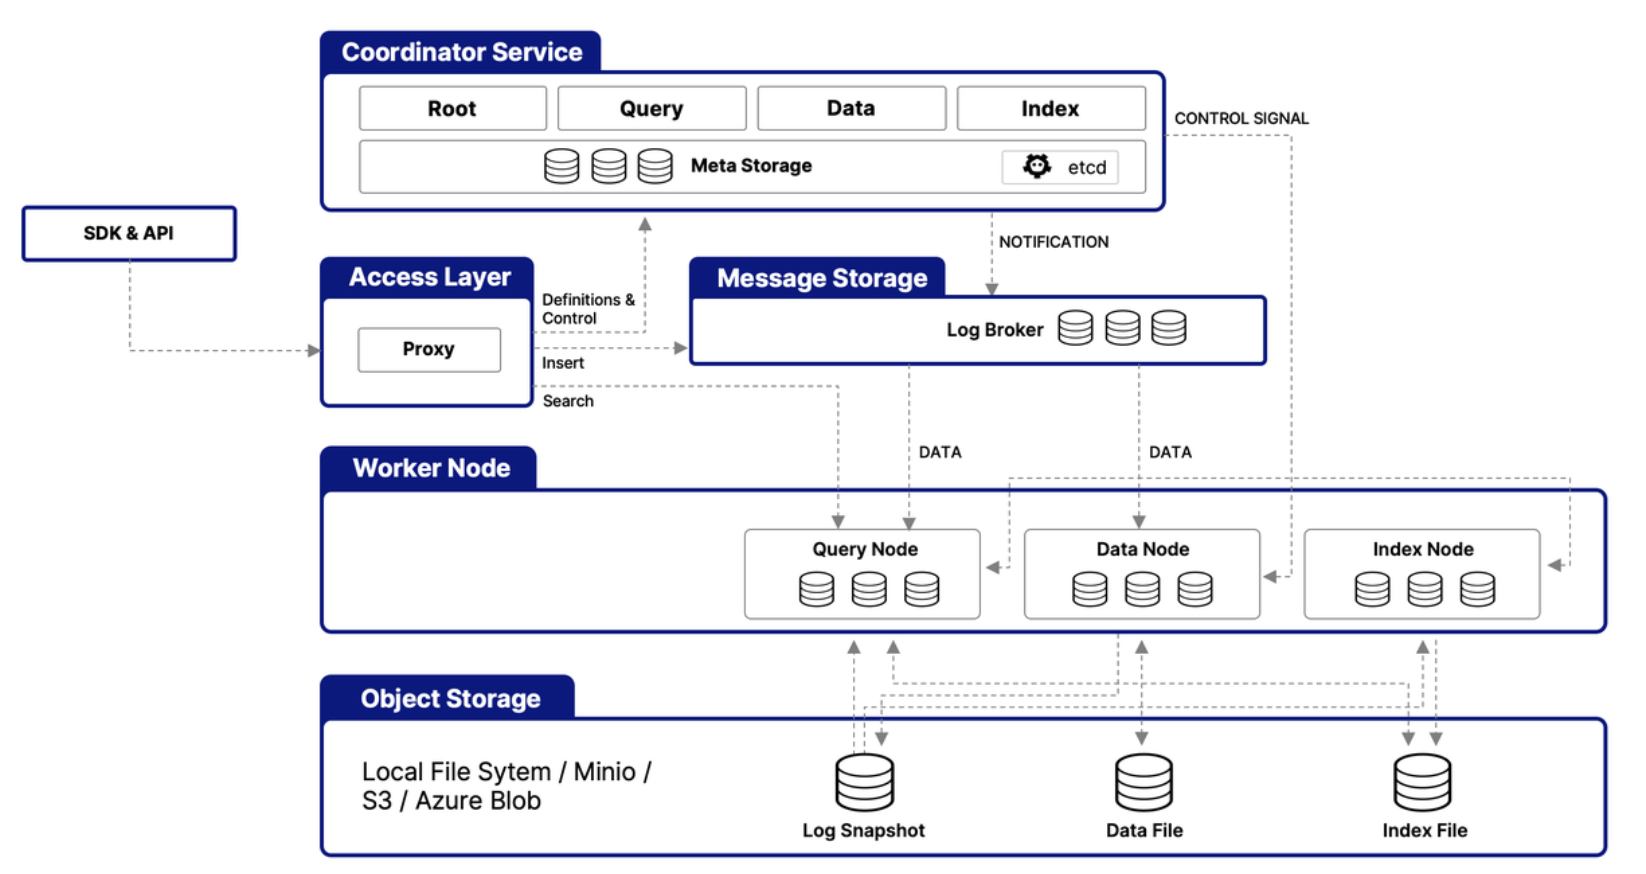

## 2. Milvus 설치 및 확인


### 2.2 MinIO 웹 콘솔
Milvus 자체가 대규모 파일 저장소가 아니기 때문에, 이러한 대용량 데이터는 외부 스토리지 시스템에 맡기는 것이 일반적입니다. 여기서 MinIO가 역할을 합니다.
- Milvus = 벡터 검색 엔진    
- MinIO = Milvus가 벡터 데이터를 저장하는 S3 호환 스토리지

MinIO 웹 콘솔
> ID: minioadmin / PW: minioadmin

```url
http://localhost:9001
```

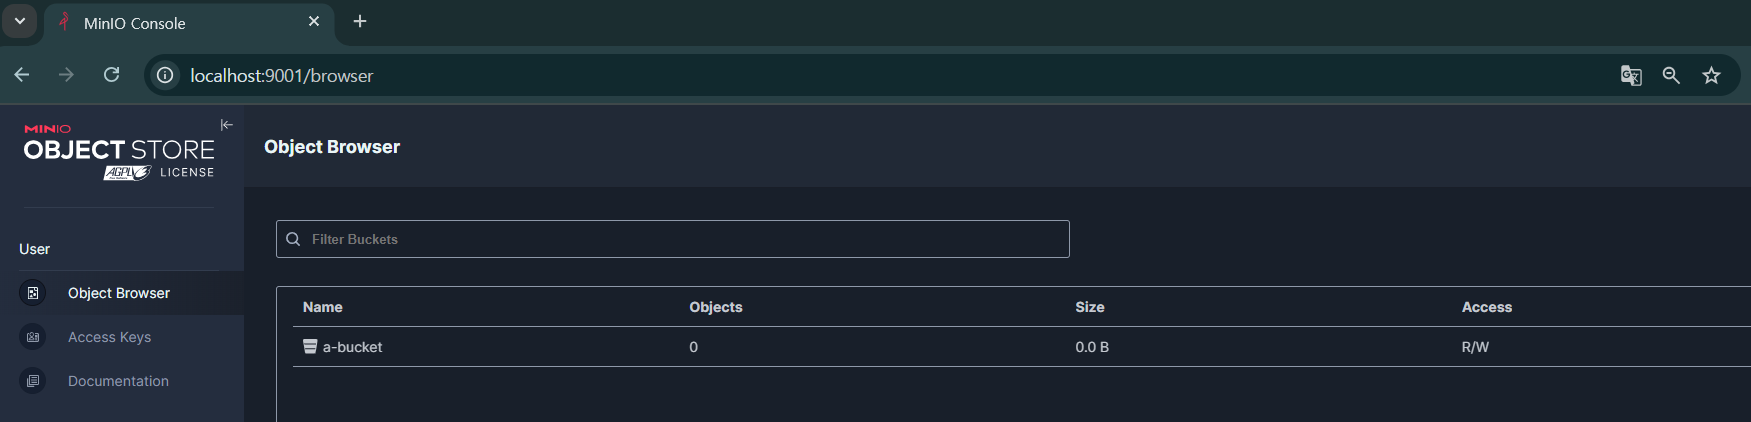

### 2.3 Attu (Milvus 관리용 Web UI)
```url
http://localhost:8000
```

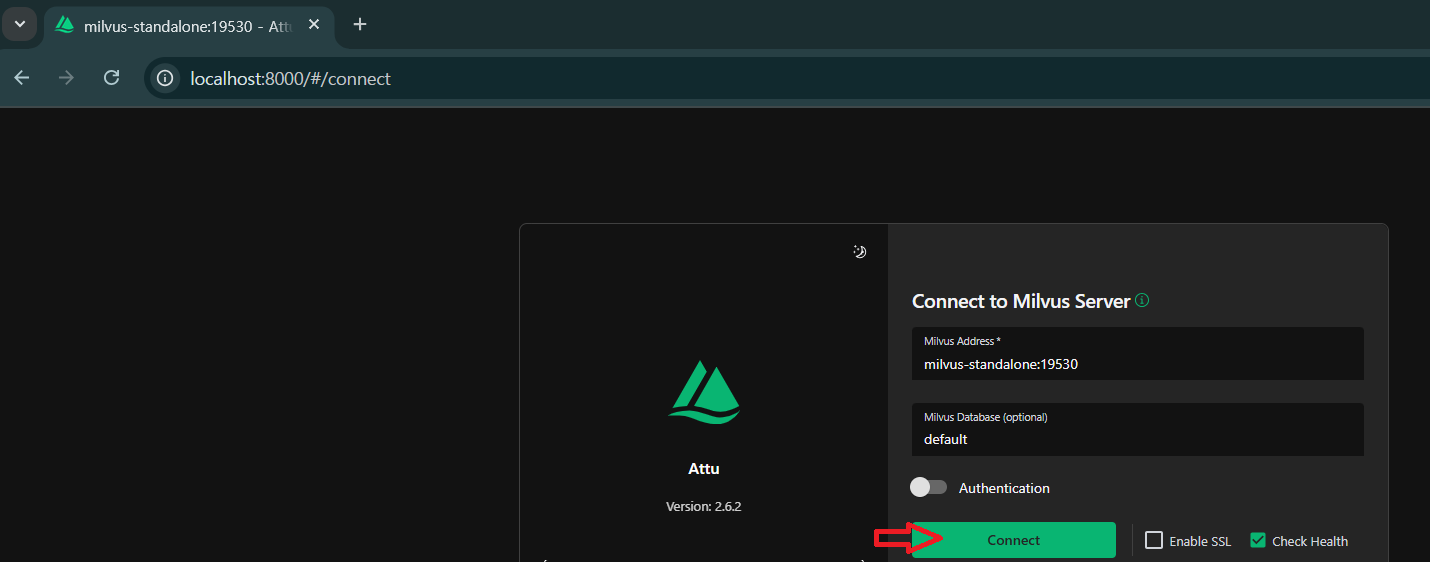

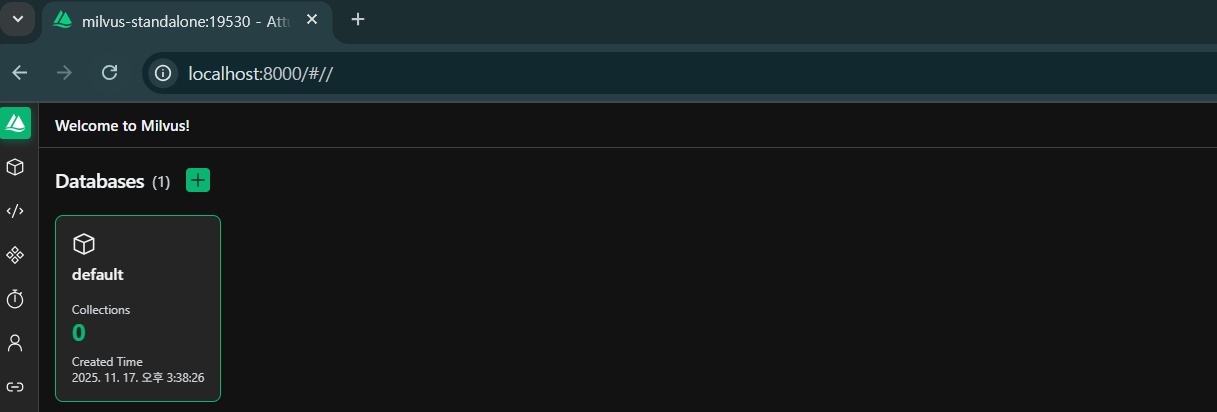

## 3. 기본 Milvus 사용법

### 3.1 연결 설정


> 인증 정보 확인

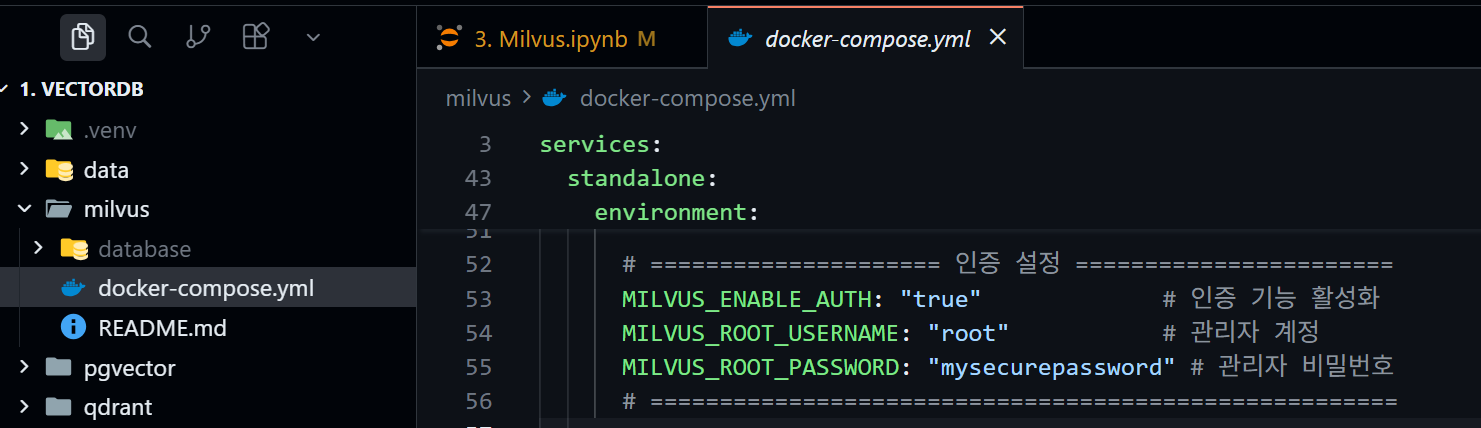

In [1]:
from pymilvus import connections

# 인증을 사용한 Milvus 접속
connections.connect(
    alias="milvus_dev",           # 연결 이름, 여러 Milvus 서버를 사용할 때 구분 가능
    host="localhost",          # Milvus 서버 주소 (Docker에서 localhost)
    port="19530",              # Milvus gRPC 포트
    user="root",               # 인증 활성화 시 Milvus 관리자 계정
    password="mysecurepassword" # 인증 활성화 시 Milvus 비밀번호
)

print("Milvus 연결 성공!")


Milvus 연결 성공!


### 3.2 컬렉션 생성
> connections을 통해 Milvus 연결 후 컬렉션 생성 가능 

In [16]:
from pymilvus import Collection, CollectionSchema, FieldSchema, DataType, utility

# 컬렉션 스키마 정의
def create_collection():
    collection_name = "document_embeddings"
    
    # 기존 컬렉션이 있으면 삭제
    if utility.has_collection(collection_name, using="milvus_dev"):
        utility.drop_collection(collection_name, using="milvus_dev")
        print(f"기존 컬렉션 '{collection_name}' 삭제 완료")
    
    # 필드 정의 (qwen3-embedding:0.6b는 1024차원 생성)
    fields = [
        FieldSchema(name="id", dtype=DataType.INT64, is_primary=True, auto_id=True),
        FieldSchema(name="text", dtype=DataType.VARCHAR, max_length=1000),
        # Embedding Model 종류에 따라 dim의 크기 수정 필요
        FieldSchema(name="embedding", dtype=DataType.FLOAT_VECTOR, dim=1024)  
    ]
    
    # 스키마 생성
    schema = CollectionSchema(fields, "문서 임베딩을 위한 컬렉션")
    
    # 컬렉션 생성
    collection = Collection(name=collection_name # 컬렉션 이름
                            , schema=schema # 스키마
                            , using="milvus_dev" # 위에서 정의한 connections의 alias
    )
    
    return collection


In [17]:
# 컬렉션 생성
collection = create_collection()
print(f"컬렉션 '{collection.name}' 생성 완료")


기존 컬렉션 'document_embeddings' 삭제 완료
컬렉션 'document_embeddings' 생성 완료


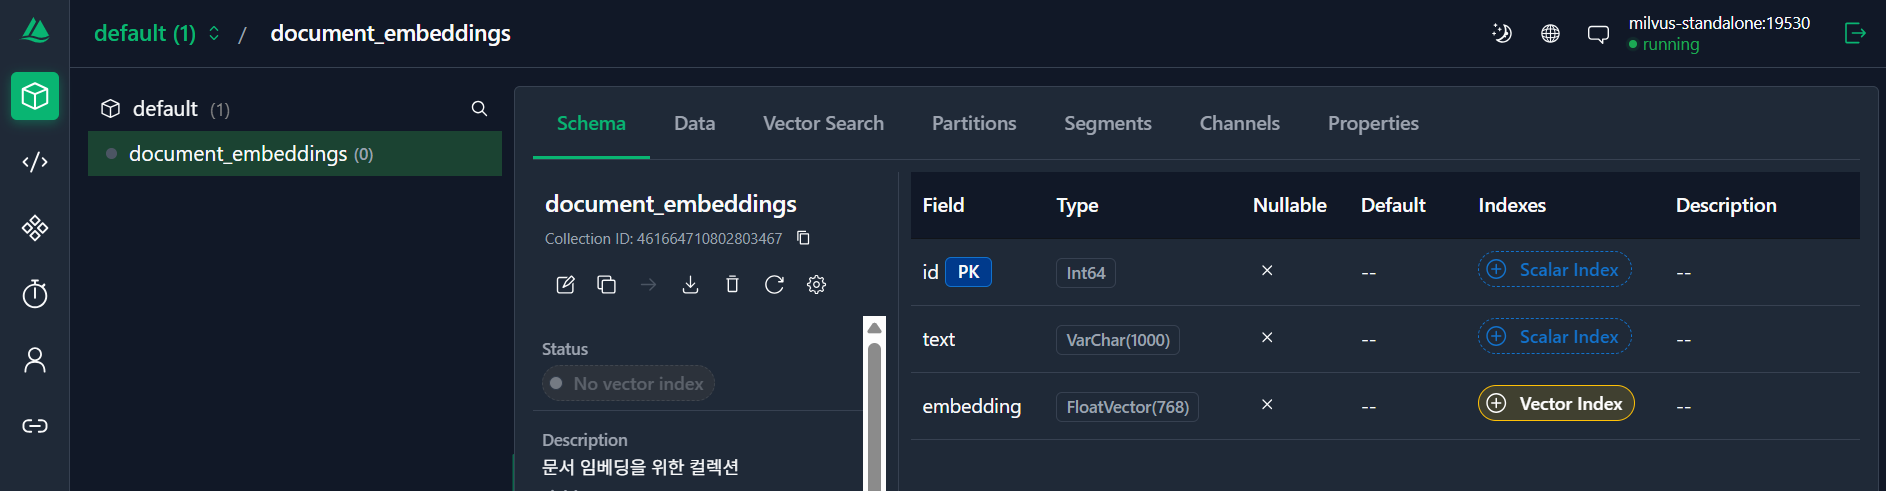

### 3.3 인덱스 생성


In [18]:
# 벡터 인덱스 생성
def create_index(collection):
    # IVF_FLAT 인덱스 생성 (정확한 검색을 위한 기본 인덱스)
    index_params = {
        "metric_type": "L2",  # 유클리드 거리
        "index_type": "IVF_FLAT",
        "params": {"nlist": 1024}
    }
    
    # 임베딩 필드에 인덱스 생성
    collection.create_index("embedding", index_params)
    print("인덱스 생성 완료")
    

In [19]:
# 인덱스 생성
create_index(collection)


인덱스 생성 완료


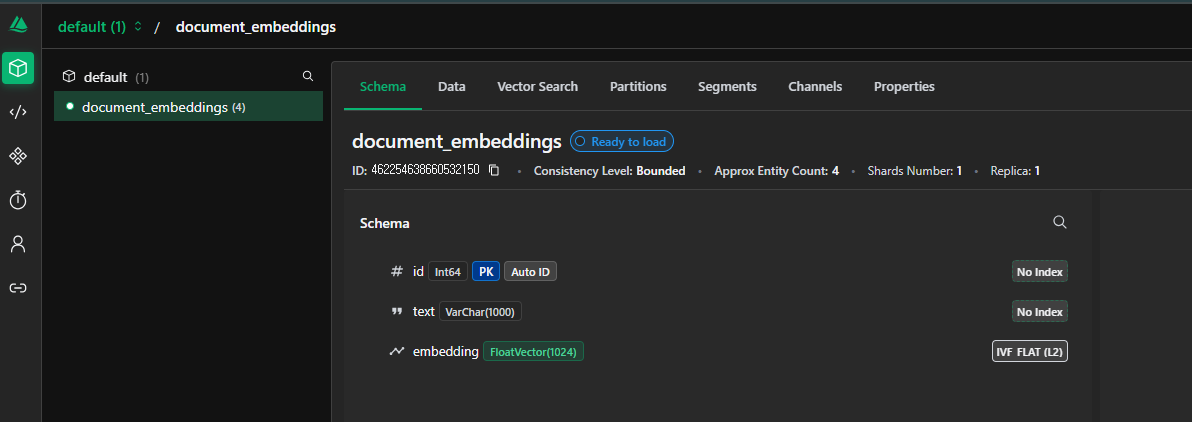

### 3.4 데이터 삽입


In [20]:
from langchain_ollama import OllamaEmbeddings

embeddings_ollama = OllamaEmbeddings(model="qwen3-embedding:0.6b")

In [ ]:
# 샘플 데이터 생성 및 삽입
def insert_data(collection):
    # 샘플 텍스트 데이터
    texts = [
        "인공지능은 컴퓨터 과학의 한 분야입니다.",
        "머신러닝은 데이터로부터 패턴을 학습합니다.",
        "딥러닝은 신경망을 사용한 머신러닝입니다.",
        "자연어처리는 컴퓨터가 인간의 언어를 이해하는 기술입니다."
    ]
    
    # 샘플 임베딩 벡터 생성
    embedding_vectors = embeddings_ollama.embed_documents(texts)
    
    # 디버깅: 임베딩 벡터 형태 확인
    print(f"임베딩 벡터 개수: {len(embedding_vectors)}")
    print(f"첫 번째 임베딩 차원: {len(embedding_vectors[0])}")
    
    # 데이터 준비 (리스트 형식으로 각 필드의 값들을 전달)
    data = [
        texts,              # text 필드
        embedding_vectors   # embedding 필드
    ]
    
    # 컬렉션에 데이터 삽입
    result = collection.insert(data)
    collection.flush()  # 디스크에 저장
    
    print(f"{len(texts)}개 문서 삽입 완료")
    print(f"삽입된 ID: {result.primary_keys}")
    

In [22]:
# 데이터 삽입
insert_data(collection)


임베딩 벡터 개수: 4
첫 번째 임베딩 차원: 1024
4개 문서 삽입 완료
삽입된 ID: [462254638660330220, 462254638660330221, 462254638660330222, 462254638660330223]


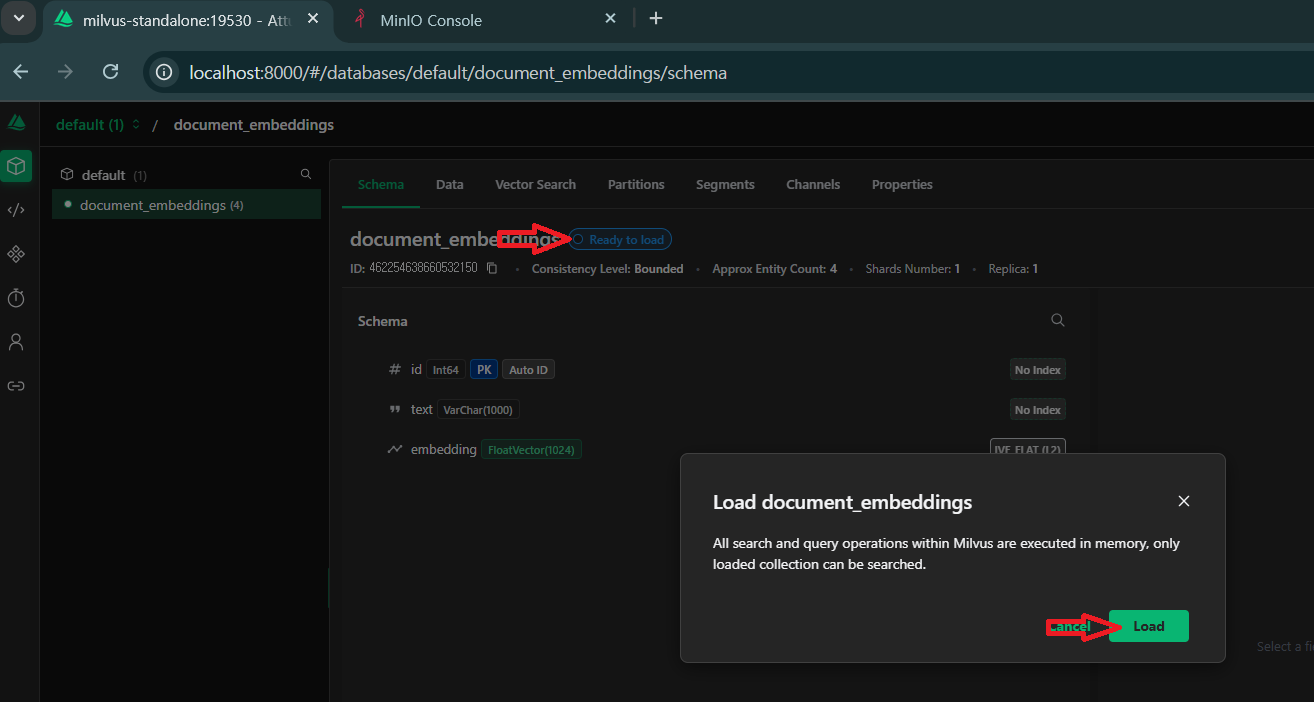

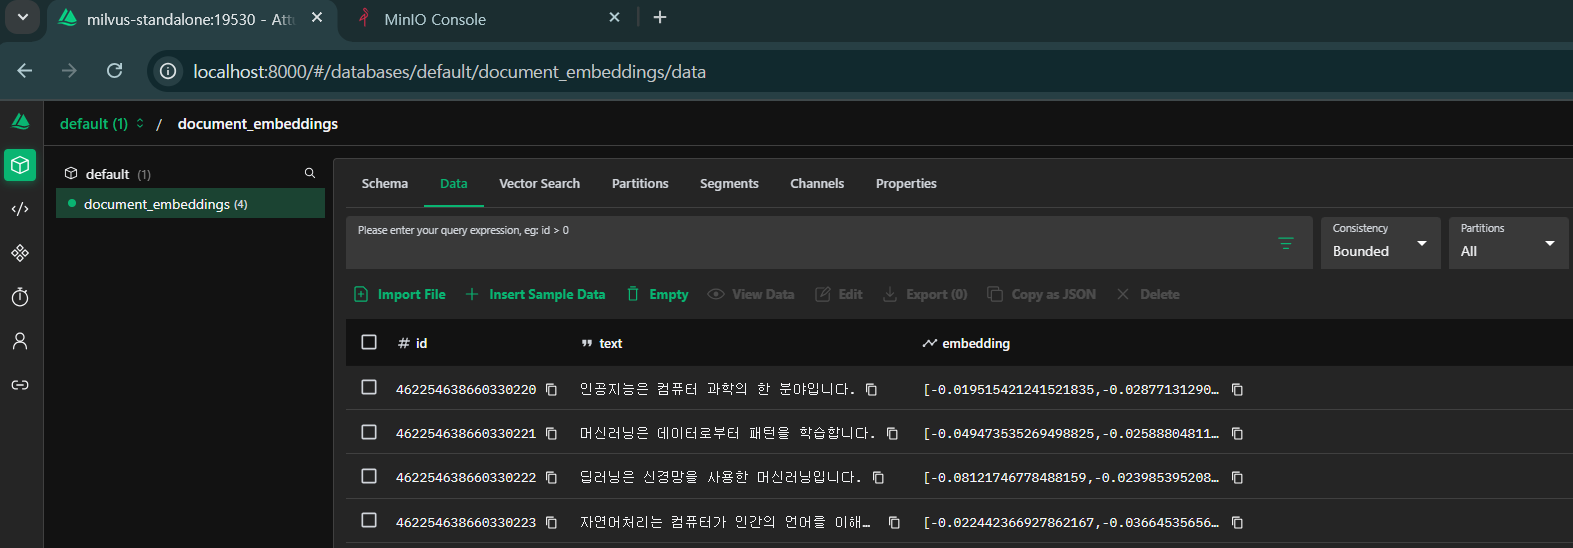

### 3.5 벡터 검색


In [23]:
# 벡터 검색 수행
def search_vectors(collection, query_vector, top_k=3):
    # 컬렉션 로드
    collection.load()
    
    # 검색 파라미터
    search_params = {
        "metric_type": "L2",
        "params": {"nprobe": 10}
    }
    
    # 벡터 검색 실행
    results = collection.search(
        data=[query_vector],
        anns_field="embedding",
        param=search_params,
        limit=top_k,
        output_fields=["text"]
    )
    
    return results


In [ ]:
# 검색 쿼리 벡터 생성
query_vector = embeddings_ollama.embed_documents(["인공지능이란?"])

In [26]:
# 검색 수행
results = search_vectors(collection, query_vector[0], top_k=3)

# 결과 출력
print("검색 결과:")
for i, result in enumerate(results[0]):
    print(f"{i+1}. 거리: {result.distance:.4f}")
    print(f"   텍스트: {result.entity.get('text')}")


검색 결과:
1. 거리: 0.9633
   텍스트: 자연어처리는 컴퓨터가 인간의 언어를 이해하는 기술입니다.
2. 거리: 0.9928
   텍스트: 인공지능은 컴퓨터 과학의 한 분야입니다.
3. 거리: 1.1494
   텍스트: 딥러닝은 신경망을 사용한 머신러닝입니다.


## [4. LangChain과 Milvus 연동](https://docs.langchain.com/oss/python/langchain/knowledge-base#milvus)


### 4.1 LangChain Milvus VectorStore 설정


In [27]:
from langchain_ollama import OllamaEmbeddings

embeddings = OllamaEmbeddings(model="qwen3-embedding:0.6b")


In [29]:
from langchain_milvus import Milvus

# Milvus VectorStore 생성
vectorstore = Milvus(
    embedding_function=embeddings,
    collection_name="rag_documents",
    connection_args={
        "host": "localhost",
        "port": "19530"
    }
)

print("LangChain Milvus VectorStore 설정 완료")


LangChain Milvus VectorStore 설정 완료


### 4.2 문서 저장 및 검색


In [30]:
from langchain_core.documents import Document

# 샘플 문서 생성
documents = [
    Document(
        page_content="인공지능(AI)은 인간의 지능을 모방하여 학습, 추론, 문제해결을 수행하는 기술입니다.",
        metadata={"source": "ai_intro.txt", "topic": "AI"}
    ),
    Document(
        page_content="머신러닝은 데이터로부터 패턴을 학습하여 예측이나 분류를 수행하는 AI의 한 분야입니다.",
        metadata={"source": "ml_intro.txt", "topic": "ML"}
    ),
    Document(
        page_content="딥러닝은 인공신경망을 사용하여 복잡한 패턴을 학습하는 머신러닝의 한 분야입니다.",
        metadata={"source": "dl_intro.txt", "topic": "DL"}
    )
]

# 문서를 벡터스토어에 추가
vectorstore.add_documents(documents)
print(f"{len(documents)}개 문서가 벡터스토어에 저장되었습니다.")


c:\dev\github\course_LLM\4. RAG\1. colab\2. Advanced RAG\1. VectorDB\.venv\Lib\site-packages\langchain_milvus\vectorstores\milvus.py:1320: UserWarning: No ids provided and auto_id is False. Setting auto_id to True automatically.
  warnings.warn(


3개 문서가 벡터스토어에 저장되었습니다.


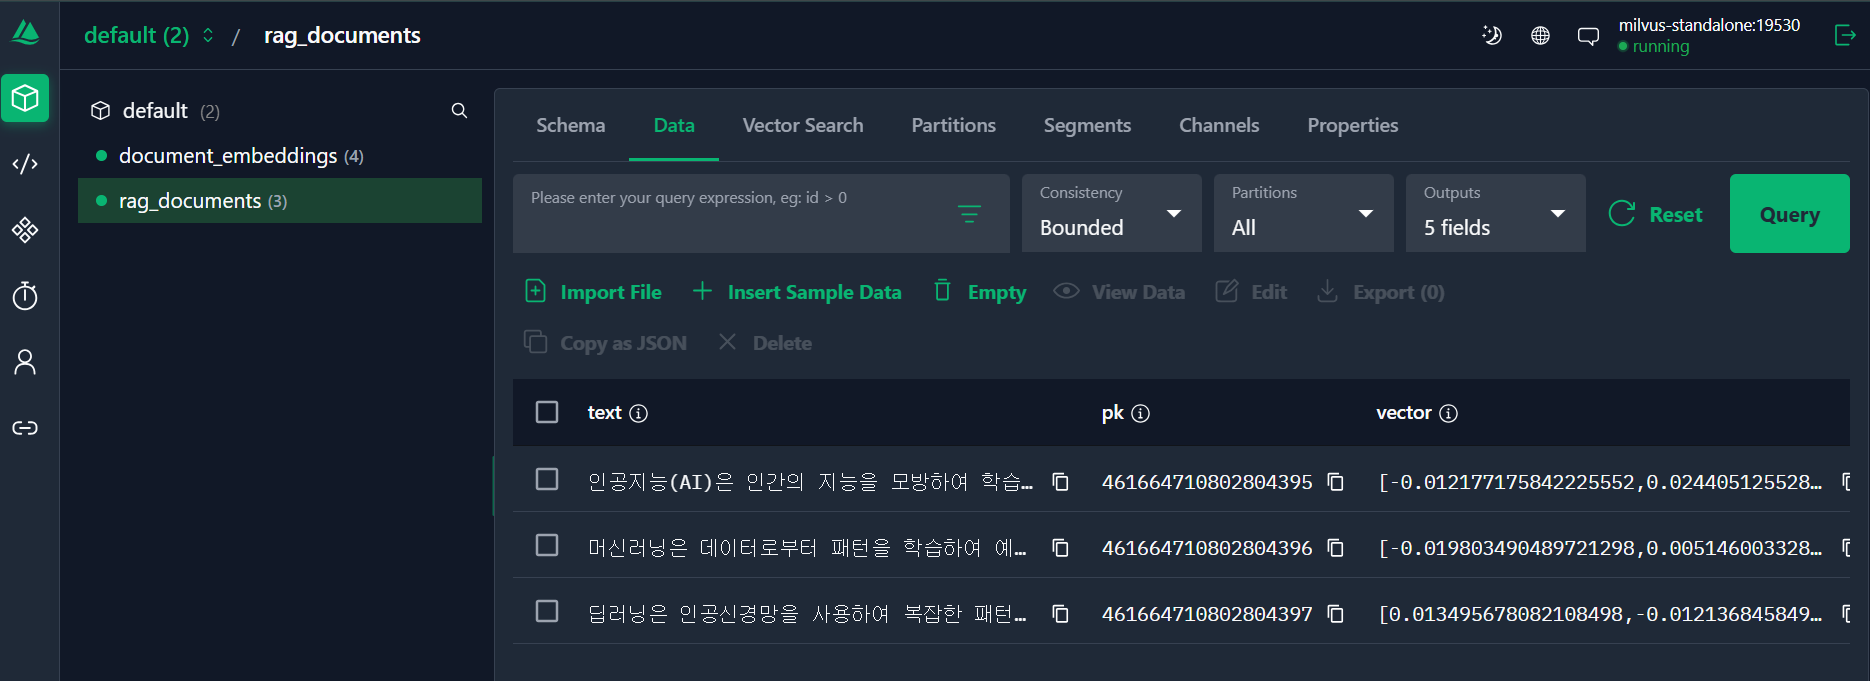

In [31]:
# 유사 문서 검색
query = "인공신경망에 대해 알려주세요"
results = vectorstore.similarity_search(query, k=2)

print(f"쿼리: {query}")
print("\n검색 결과:")
for i, doc in enumerate(results):
    print(f"{i+1}. {doc.page_content}")
    print(f"   메타데이터: {doc.metadata}")


쿼리: 인공신경망에 대해 알려주세요

검색 결과:
1. 딥러닝은 인공신경망을 사용하여 복잡한 패턴을 학습하는 머신러닝의 한 분야입니다.
   메타데이터: {'source': 'dl_intro.txt', 'topic': 'DL', 'pk': 462254638660330227}
2. 머신러닝은 데이터로부터 패턴을 학습하여 예측이나 분류를 수행하는 AI의 한 분야입니다.
   메타데이터: {'source': 'ml_intro.txt', 'topic': 'ML', 'pk': 462254638660330226}


### 4.3 RAG 체인 구성


In [32]:
from langchain_ollama.chat_models import ChatOllama 

llm = ChatOllama(
    model="gemma3:4b",
    temperature=0.1,
    top_p=1.0,
    num_predict=256,
    keep_alive="5m"
)

In [33]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

# Retriever 설정
retriever = vectorstore.as_retriever(search_kwargs={"k": 2})

# 프롬프트 템플릿 정의
prompt = ChatPromptTemplate.from_template("""
    Answer the question based on the context:

    <context>
    {context}
    </context>

    Question: {question}
""")

# 문서를 문자열로 변환하는 함수
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

# LCEL 방식의 RAG 체인 구성
qa_chain = (
    {
        "context": retriever | format_docs,
        "question": RunnablePassthrough()
    }
    | prompt
    | llm
    | StrOutputParser()
)


In [34]:
# 질문 답변 실행
question = "머신러닝과 딥러닝의 차이점은 무엇인가요?"

# LCEL 체인에 질문을 문자열로 전달
answer = qa_chain.invoke(question)

print(f"질문: {question}")
print(f"답변: {answer}")


c:\dev\github\course_LLM\4. RAG\1. colab\2. Advanced RAG\1. VectorDB\.venv\Lib\site-packages\pydantic\v1\main.py:1054: UserWarning: LangSmith now uses UUID v7 for run and trace identifiers. This warning appears when passing custom IDs. Please use: from langsmith import uuid7
            id = uuid7()
Future versions will require UUID v7.
  input_data = validator(cls_, input_data)


질문: 머신러닝과 딥러닝의 차이점은 무엇인가요?
답변: 머신러닝은 데이터로부터 패턴을 학습하여 예측이나 분류를 수행하는 AI의 한 분야이고, 딥러닝은 인공신경망을 사용하여 복잡한 패턴을 학습하는 머신러닝의 한 분야입니다. 즉, 딥러닝은 머신러닝의 한 종류입니다.


## 5. 고급 기능 및 최적화

### 5.1 다양한 인덱스 타입 비교


In [35]:
# HNSW 인덱스 (빠른 검색, 높은 정확도)
hnsw_params = {
    "metric_type": "L2",
    "index_type": "HNSW",
    "params": {"M": 16, "efConstruction": 200}
}

In [36]:
# IVF_SQ8 인덱스 (메모리 효율적, 양호한 성능)
ivf_sq8_params = {
    "metric_type": "L2",
    "index_type": "IVF_SQ8",
    "params": {"nlist": 1024}
}

In [37]:
# ANNOY 인덱스 (빠른 근사 검색, 낮은 메모리 사용)
annoy_params = {
    "metric_type": "L2",
    "index_type": "ANNOY",
    "params": {"n_trees": 100}
}

### 5.2 하이브리드 검색 (벡터 + 키워드)


In [ ]:
# 하이브리드 검색 구현
def hybrid_search(collection, query_vector, keyword_filter, top_k=5):
    # 벡터 검색
    vector_results = collection.search(
        data=[query_vector], # 벡터 데이터
        anns_field="embedding", # 임베딩 필드
        param=annoy_params, # 검색 파라미터
        limit=top_k, # 검색 결과 수
        output_fields=["text", "id"] # 출력 필드
    )
    
    # 키워드 필터링 (실제로는 더 복잡한 필터링 로직 사용)
    filtered_results = []
    for result in vector_results[0]: 
        if keyword_filter.lower() in result.entity.get('text', '').lower():
            filtered_results.append(result)
    
    return filtered_results


In [ ]:
# 하이브리드 검색 예제
keyword = "인공지능"
query_vector = embeddings_ollama.embed_query(keyword)

hybrid_results = hybrid_search(collection, query_vector, keyword, top_k=3)

print(f"하이브리드 검색 결과 (키워드: '{keyword}'):")
for i, result in enumerate(hybrid_results):
    print(f"{i+1}. {result.entity.get('text')}")
    print(f"   거리: {result.distance:.4f}")


하이브리드 검색 결과 (키워드: '인공지능'):
1. 인공지능은 컴퓨터 과학의 한 분야입니다.
   거리: 1.1407


### 5.3 성능 모니터링 및 최적화


In [43]:
import time

# 성능 측정 함수
def measure_search_performance(collection, query_vector, iterations=100):
    collection.load()
    
    start_time = time.time()
    
    for _ in range(iterations):
        results = collection.search(
            data=[query_vector],
            anns_field="embedding",
            param={"metric_type": "L2", "params": {"nprobe": 10}},
            limit=5
        )
    
    end_time = time.time()
    avg_time = (end_time - start_time) / iterations
    
    print(f"평균 검색 시간: {avg_time*1000:.2f}ms")
    print(f"초당 검색 횟수: {1/avg_time:.2f} QPS")
    
    return avg_time


In [44]:
# 성능 측정
keyword = "인공지능"
query_vector = embeddings_ollama.embed_query(keyword)
measure_search_performance(collection, query_vector, iterations=50)


평균 검색 시간: 2.45ms
초당 검색 횟수: 408.55 QPS


0.002447686195373535